# 04 — Time-Delay Embedding (TDE)

Calcul des paramètres d'embedding `τ` (AMI) et `m` (FNN) pour chaque essai,
puis agrégation par participant (médiane des 3 conditions).

## Méthode

**Signal utilisé** : `signal_final` 100 Hz, **zone perturbation exclue** :
concaténation pre-perturbation `[crop_start, entry−5s]` + post-perturbation `[exit+30s, end]`.

Justification :
- ~95 cycles seulement en pre-perturbation seul → sous le minimum (200-300 cycles, Mehdizadeh 2020)
- Concaténation → ~525-630 cycles, m stable
- Caractérise la marche normale du sujet, pas la transition perturbée

**Paramètres** :
- `max_lag = 100` (à 100Hz = 1s max)
- `max_dim = 10`
- `r_threshold = 15` (Kennel et al. 1992)
- `fnn_threshold = 10%` (Mehdizadeh 2020)
- `τ` = premier minimum local de AMI
- `m` = première dim avec FNN_rate < 10%

**Agrégation** : `τ_p = round(median(τ_sil, τ_tr, τ_bm))` et idem pour `m_p`.
Postulat : `τ`/`m` sont des propriétés du sujet (cadence, complexité dynamique),
pas de la condition expérimentale.

In [1]:
from resilience import paths, participants, config
from resilience.io import writer
from resilience.processing import detection, tde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

## Chargement essais + recalcul détection bbox

On recharge tous les essais non-exclus et on relance la détection bbox pour avoir `entry_t` et `exit_t` (référentiel BRUT, avec recalage `+crop_start_s`).

Le `signal_final` lui est en référentiel POST-CROP → il faut donc soustraire `crop_start_s` aux timestamps de détection avant d'indexer le signal.

In [2]:
def load_trials_with_detection():
    """Charge tous les essais non-exclus avec leur signal_final et entry/exit bbox."""
    trials = {}
    for code, P in participants.PARTICIPANTS.items():
        for cond, trial in P.trials.items():
            if trial.excluded:
                continue
            try:
                d = writer.load_processed(code, cond)
            except FileNotFoundError:
                print(f"  ⚠️  Pas de .npz pour {code}/{cond}")
                continue

            # Sacrum XY pour bbox
            dos_xy = np.stack([d[f'raw_Dos{i:02d}'][:, :2] for i in range(1, 5)], axis=0)
            sacrum_xy = np.nanmean(dos_xy, axis=0)
            for ax in range(2):
                col = sacrum_xy[:, ax]
                if np.isnan(col).any():
                    idx = np.arange(len(col))
                    valid = ~np.isnan(col)
                    if valid.sum() >= 2:
                        col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
                    sacrum_xy[:, ax] = col

            # Détection bbox
            det = detection.detect_sand_by_bbox(sacrum_xy)
            offset = trial.crop_start_s if trial.crop_start_s is not None else 0.0
            entry_brut = det['entry_t'] + offset if not np.isnan(det['entry_t']) else np.nan
            exit_brut  = det['exit_t']  + offset if not np.isnan(det['exit_t'])  else np.nan

            trials[(code, cond)] = {
                'signal_final': d['signal_final'].astype(float),
                'time_final':   d['time_final'].astype(float),  # post-crop référentiel
                'crop_start_s': offset,
                'entry_brut':   entry_brut,
                'exit_brut':    exit_brut,
            }
    return trials

TRIALS = load_trials_with_detection()
print(f"✅ {len(TRIALS)} essais chargés")

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_20864\3392125442.py:16: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)


✅ 38 essais chargés


## Construction du signal `clean` (zone perturbation exclue)

Pour chaque essai : on coupe `[entry−5s, exit+30s]` (référentiel BRUT) et on concatène pre + post.

In [3]:
MARGIN_PRE_S  = 5.0
MARGIN_POST_S = 30.0

def build_clean_signal(trial_data):
    """
    Concatène pre-perturbation + post-perturbation pour analyse TDE stationnaire.

    Le signal_final est en référentiel POST-CROP (t=0 au début du signal traité).
    entry_brut/exit_brut sont en référentiel BRUT (depuis t=0 du .mat).
    → on convertit en post-crop avant de masquer.
    """
    sig  = trial_data['signal_final']
    t    = trial_data['time_final']    # post-crop, démarre à 0
    offs = trial_data['crop_start_s']

    if np.isnan(trial_data['entry_brut']):
        return sig.copy(), len(sig), 0  # pas de perturbation détectée → garde tout

    # Conversion vers référentiel post-crop
    entry_local = trial_data['entry_brut'] - offs
    exit_local  = trial_data['exit_brut']  - offs

    # Masques
    mask_pre  = t < (entry_local - MARGIN_PRE_S)
    mask_post = t > (exit_local  + MARGIN_POST_S)

    sig_clean = np.concatenate([sig[mask_pre], sig[mask_post]])
    n_excluded = int(((~mask_pre) & (~mask_post)).sum())
    return sig_clean, len(sig_clean), n_excluded


# Test sur un essai
test_key = list(TRIALS.keys())[0]
sig_clean, n_kept, n_excl = build_clean_signal(TRIALS[test_key])
print(f"Test {test_key} : signal original = {len(TRIALS[test_key]['signal_final'])} samples")
print(f"         clean = {n_kept} samples ({n_kept/100:.1f}s)")
print(f"         excluded = {n_excl} samples ({n_excl/100:.1f}s)")

Test ('001CrMa', 'silence') : signal original = 42000 samples
         clean = 38014 samples (380.1s)
         excluded = 3986 samples (39.9s)


## Calcul AMI + FNN sur les 38 essais

In [4]:
# Paramètres TDE (literature-aligned)
MAX_LAG = 100
MAX_DIM = 10
FNN_THRESHOLD = 10.0   # %  (Mehdizadeh 2020, vs 1% de config.py)
FNN_R = 15.0           # Kennel 1992

results = []
tde_curves = {}  # pour les plots

for (code, cond), data in TRIALS.items():
    sig_clean, n_kept, n_excl = build_clean_signal(data)
    duration_s = n_kept / config.FS_CLEAN
    n_cycles_estim = int(duration_s * 1.75)  # approx à 1.75 Hz moyen

    if n_kept < 200 * 100 / 1.75:  # min 200 cycles
        print(f"  ⚠️  {code}/{cond} : seulement {n_cycles_estim} cycles (<200)")

    # AMI
    tau, ami_values = tde.compute_ami(sig_clean, max_lag=MAX_LAG)

    # FNN avec params explicites
    m, fnn_rates = tde.compute_fnn(sig_clean, max_dim=MAX_DIM, tau=tau,
                                     threshold=FNN_THRESHOLD, r_threshold=FNN_R)

    results.append({
        'participant':   code,
        'condition':     cond,
        'n_samples':     n_kept,
        'duration_s':    round(duration_s, 1),
        'n_cycles_est':  n_cycles_estim,
        'tau':           tau,
        'm':             m,
    })
    tde_curves[(code, cond)] = {
        'ami': ami_values,
        'fnn': fnn_rates,
        'tau': tau,
        'm':   m,
    }
    print(f"  {code}/{cond:22s} : τ={tau:3d}, m={m}, n_cycles≈{n_cycles_estim}")

df_tde = pd.DataFrame(results)
print(f"\n✅ TDE calculé sur {len(df_tde)} essais")
df_tde

  001CrMa/silence                : τ= 17, m=4, n_cycles≈665
  001CrMa/tempo_random           : τ= 16, m=4, n_cycles≈666
  001CrMa/beatmove_adaptatif     : τ= 16, m=4, n_cycles≈452
  002CrPa/silence                : τ= 17, m=4, n_cycles≈665
  002CrPa/beatmove_adaptatif     : τ= 17, m=4, n_cycles≈560
  002CrPa/tempo_random           : τ= 17, m=4, n_cycles≈630
  003BrLu/silence                : τ= 16, m=4, n_cycles≈645
  003BrLu/tempo_random           : τ= 18, m=4, n_cycles≈527
  003BrLu/beatmove_adaptatif     : τ= 18, m=4, n_cycles≈666
  004CaGe/silence                : τ= 18, m=4, n_cycles≈654
  004CaGe/tempo_random           : τ= 16, m=4, n_cycles≈596
  004CaGe/beatmove_adaptatif     : τ= 17, m=4, n_cycles≈666
  005DeJe/tempo_random           : τ= 16, m=4, n_cycles≈562
  005DeJe/beatmove_adaptatif     : τ= 16, m=4, n_cycles≈405
  006MoCa/silence                : τ= 16, m=4, n_cycles≈572
  006MoCa/tempo_random           : τ= 15, m=4, n_cycles≈314
  006MoCa/beatmove_adaptatif     : τ= 15

,participant,condition,n_samples,duration_s,n_cycles_est,tau,m
0,001CrMa,silence,38014,380.1,665,17,4
1,001CrMa,tempo_random,38065,380.6,666,16,4
2,001CrMa,beatmove_adaptatif,25883,258.8,452,16,4
3,002CrPa,silence,38005,380.1,665,17,4
4,002CrPa,beatmove_adaptatif,32007,320.1,560,17,4
5,002CrPa,tempo_random,36005,360.1,630,17,4
6,003BrLu,silence,36903,369.0,645,16,4
7,003BrLu,tempo_random,30116,301.2,527,18,4
8,003BrLu,beatmove_adaptatif,38109,381.1,666,18,4
9,004CaGe,silence,37407,374.1,654,18,4


## Agrégation par participant

In [5]:
df_p = df_tde.groupby('participant').agg(
    n_trials   = ('tau', 'count'),
    tau_min    = ('tau', 'min'),
    tau_med    = ('tau', 'median'),
    tau_max    = ('tau', 'max'),
    m_min      = ('m',   'min'),
    m_med      = ('m',   'median'),
    m_max      = ('m',   'max'),
).reset_index()

df_p['tau_p'] = df_p['tau_med'].round().astype(int)
df_p['m_p']   = df_p['m_med'].round().astype(int)

# Variabilité inter-conditions
df_p['tau_range'] = df_p['tau_max'] - df_p['tau_min']
df_p['m_range']   = df_p['m_max']   - df_p['m_min']

print("Paramètres TDE agrégés par participant (médiane des 3 conditions) :")
df_p[['participant', 'n_trials', 'tau_min', 'tau_med', 'tau_max', 'tau_range',
      'm_min', 'm_med', 'm_max', 'm_range', 'tau_p', 'm_p']]

Paramètres TDE agrégés par participant (médiane des 3 conditions) :


,participant,n_trials,tau_min,tau_med,tau_max,tau_range,m_min,m_med,m_max,m_range,tau_p,m_p
0,001CrMa,3,16,16.0,17,1,4,4.0,4,0,16,4
1,002CrPa,3,17,17.0,17,0,4,4.0,4,0,17,4
2,003BrLu,3,16,18.0,18,2,4,4.0,4,0,18,4
3,004CaGe,3,16,17.0,18,2,4,4.0,4,0,17,4
4,005DeJe,2,16,16.0,16,0,4,4.0,4,0,16,4
5,006MoCa,3,15,15.0,16,1,4,4.0,4,0,15,4
6,007MoMa,1,15,15.0,15,0,4,4.0,4,0,15,4
7,008RiMo,2,16,16.5,17,1,4,4.0,4,0,16,4
8,009DeFr,3,16,16.0,16,0,4,4.0,4,0,16,4
9,010DeYv,3,15,15.0,16,1,4,4.0,4,0,15,4


In [6]:
# Stats descriptives
print("Distribution globale :\n")
print(df_tde[['tau', 'm', 'duration_s', 'n_cycles_est']].describe().round(1))

print(f"\nVariabilité inter-conditions :")
print(f"  tau_range > 5 samples : {(df_p['tau_range'] > 5).sum()} / {len(df_p)} participants")
print(f"  m_range  > 1         : {(df_p['m_range'] > 1).sum()} / {len(df_p)} participants")

Distribution globale :

        tau     m  duration_s  n_cycles_est
count  38.0  38.0        38.0          38.0
mean   16.3   4.0       339.6         593.9
std     1.2   0.0        64.9         113.6
min    14.0   4.0       169.3         296.0
25%    16.0   4.0       320.5         560.5
50%    16.0   4.0       380.2         665.0
75%    17.0   4.0       381.1         666.0
max    19.0   4.0       382.1         668.0

Variabilité inter-conditions :
  tau_range > 5 samples : 0 / 14 participants
  m_range  > 1         : 0 / 14 participants


## Plots : courbes AMI + FNN par participant

1 figure = 1 participant, 2 subplots (AMI / FNN), 3 courbes (conditions superposées).

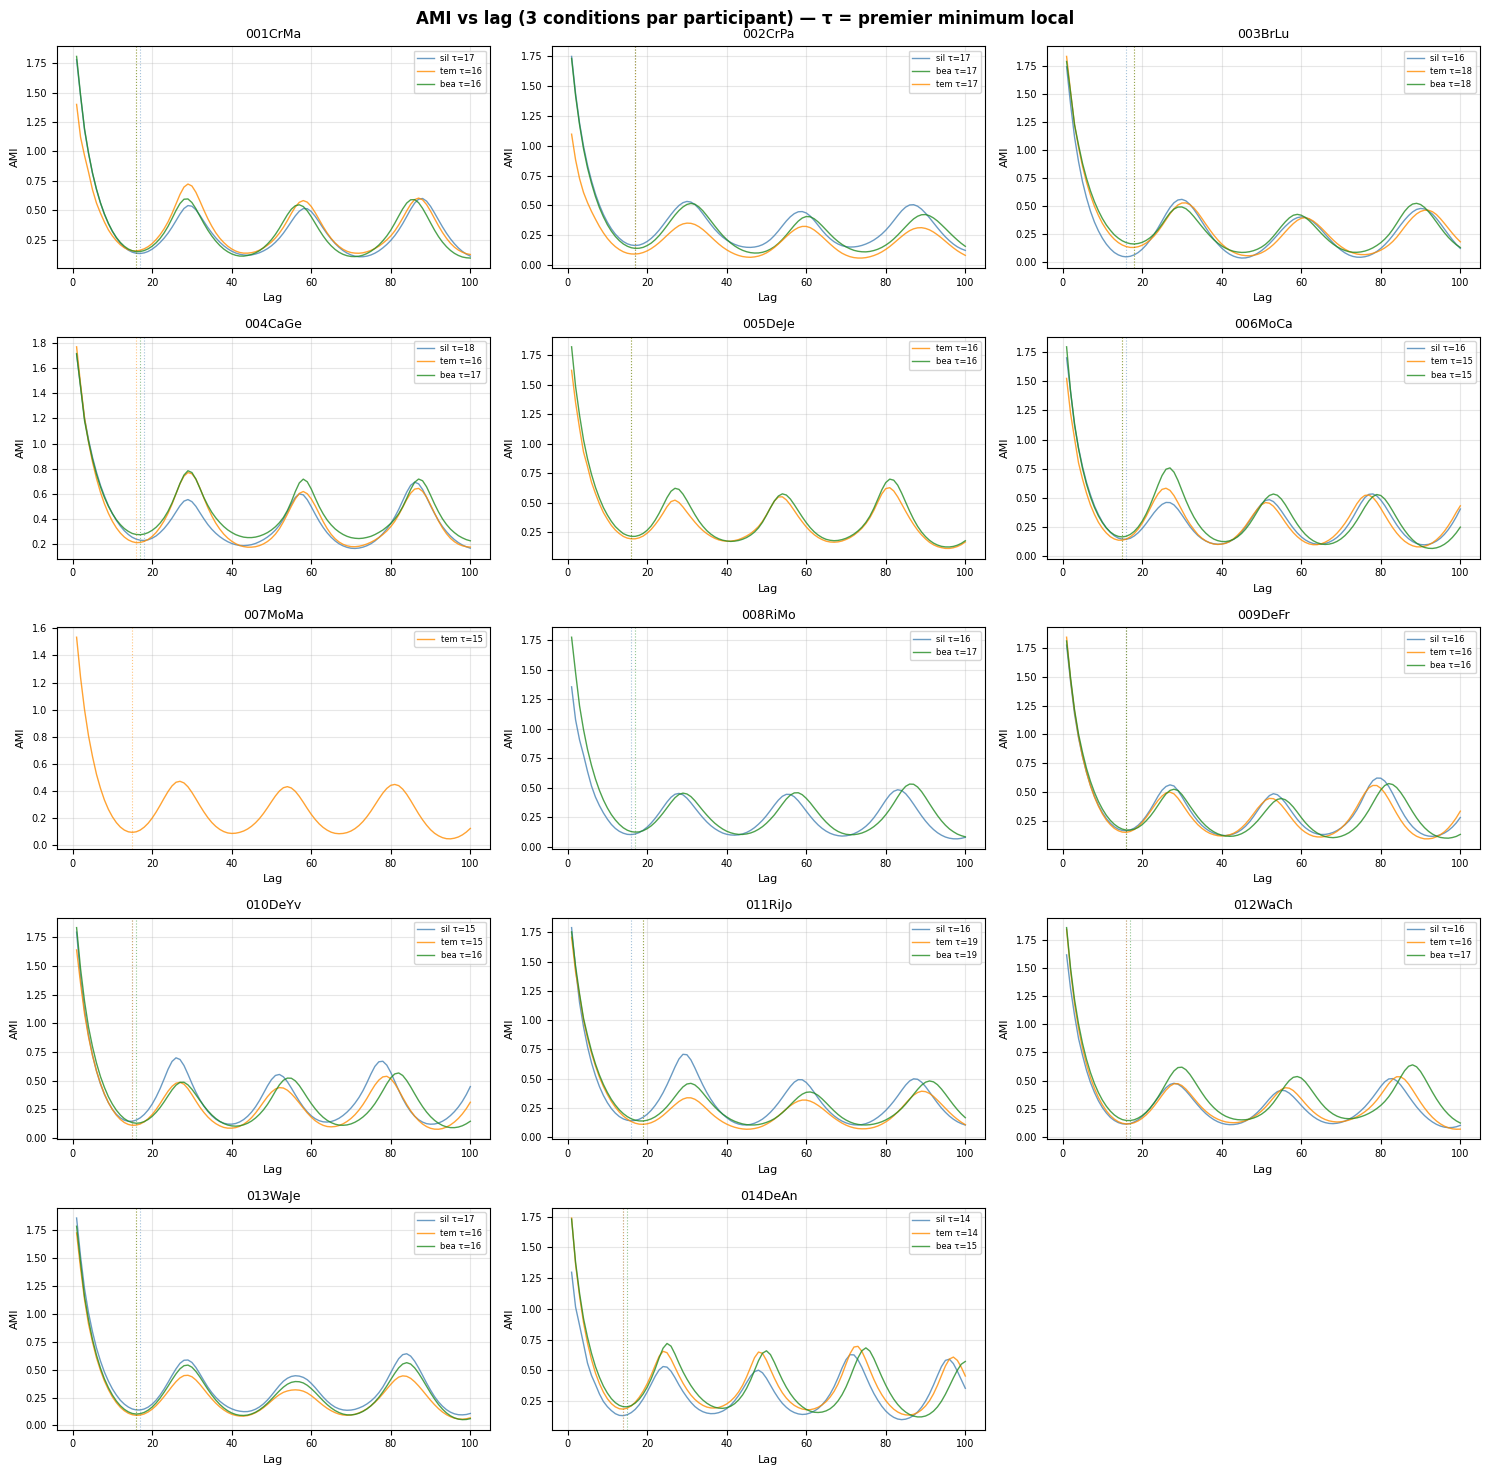

In [7]:
COND_COLORS = {
    'silence':            'steelblue',
    'tempo_random':       'darkorange',
    'beatmove_adaptatif': 'forestgreen',
}

by_p = {}
for (code, cond), curves in tde_curves.items():
    by_p.setdefault(code, {})[cond] = curves

n_p = len(by_p)
n_cols = 3
n_rows = (n_p + n_cols - 1) // n_cols

# AMI
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
for i, (code, curves) in enumerate(sorted(by_p.items())):
    ax = axes.flat[i]
    for cond, c in curves.items():
        ax.plot(range(1, len(c['ami'])+1), c['ami'],
                color=COND_COLORS[cond], linewidth=1, alpha=0.8,
                label=f"{cond[:3]} τ={c['tau']}")
        ax.axvline(c['tau'], color=COND_COLORS[cond], linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_title(code, fontsize=9)
    ax.set_xlabel('Lag', fontsize=8)
    ax.set_ylabel('AMI', fontsize=8)
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)
for j in range(i+1, n_rows*n_cols):
    axes.flat[j].axis('off')
plt.suptitle('AMI vs lag (3 conditions par participant) — τ = premier minimum local',
             fontweight='bold')
plt.tight_layout()
plt.savefig('04_ami_curves.png', dpi=80, bbox_inches='tight')
plt.show()

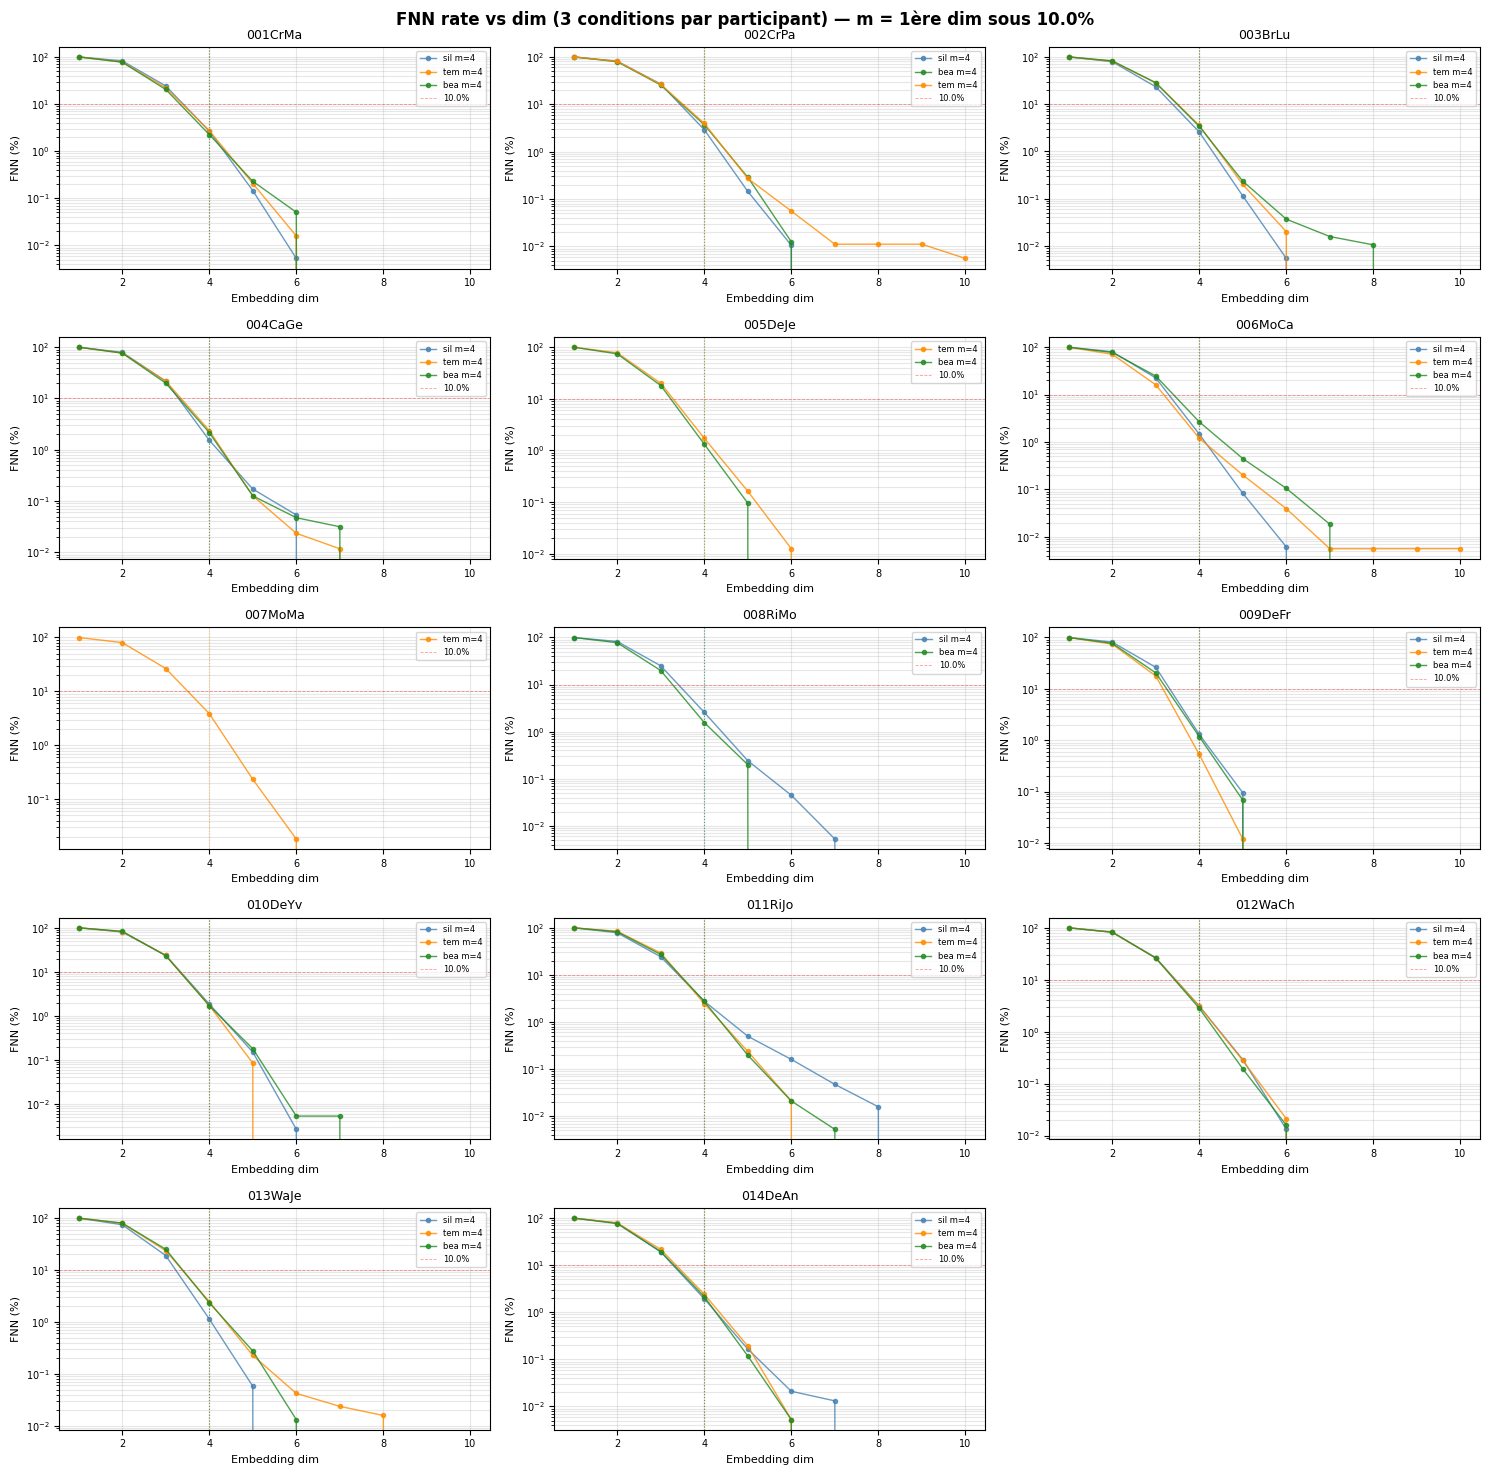

In [8]:
# FNN
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
for i, (code, curves) in enumerate(sorted(by_p.items())):
    ax = axes.flat[i]
    for cond, c in curves.items():
        ax.plot(range(1, len(c['fnn'])+1), c['fnn'],
                color=COND_COLORS[cond], linewidth=1, alpha=0.8,
                marker='o', markersize=3,
                label=f"{cond[:3]} m={c['m']}")
        ax.axvline(c['m'], color=COND_COLORS[cond], linestyle=':', linewidth=0.8, alpha=0.5)
    ax.axhline(FNN_THRESHOLD, color='red', linestyle='--', linewidth=0.6, alpha=0.4, label=f'{FNN_THRESHOLD}%')
    ax.set_title(code, fontsize=9)
    ax.set_xlabel('Embedding dim', fontsize=8)
    ax.set_ylabel('FNN (%)', fontsize=8)
    ax.set_yscale('log')
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(alpha=0.3, which='both')
    ax.tick_params(labelsize=7)
for j in range(i+1, n_rows*n_cols):
    axes.flat[j].axis('off')
plt.suptitle(f'FNN rate vs dim (3 conditions par participant) — m = 1ère dim sous {FNN_THRESHOLD}%',
             fontweight='bold')
plt.tight_layout()
plt.savefig('04_fnn_curves.png', dpi=80, bbox_inches='tight')
plt.show()

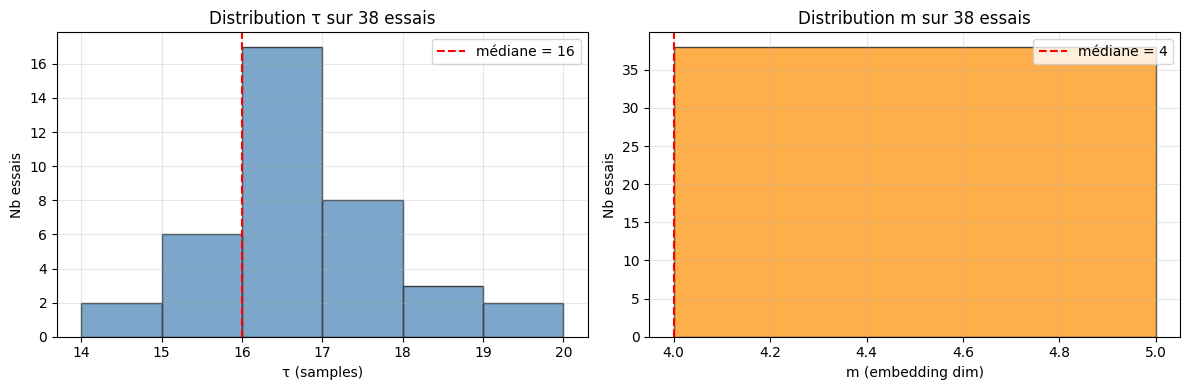

In [9]:
# Distributions globales tau / m
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_tde['tau'], bins=range(df_tde['tau'].min(), df_tde['tau'].max()+2),
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_tde['tau'].median(), color='red', linestyle='--',
                label=f"médiane = {df_tde['tau'].median():.0f}")
axes[0].set_xlabel('τ (samples)')
axes[0].set_ylabel('Nb essais')
axes[0].set_title(f'Distribution τ sur {len(df_tde)} essais')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(df_tde['m'], bins=range(df_tde['m'].min(), df_tde['m'].max()+2),
             color='darkorange', edgecolor='black', alpha=0.7)
axes[1].axvline(df_tde['m'].median(), color='red', linestyle='--',
                label=f"médiane = {df_tde['m'].median():.0f}")
axes[1].set_xlabel('m (embedding dim)')
axes[1].set_ylabel('Nb essais')
axes[1].set_title(f'Distribution m sur {len(df_tde)} essais')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('04_distributions.png', dpi=80, bbox_inches='tight')
plt.show()

## Export résultats

Deux CSV :
- `04_tde_per_trial.csv` : params par essai (utile pour debug, alternative si on veut tester l'approche "par essai")
- `04_tde_per_participant.csv` : params agrégés (à utiliser au notebook 05)

In [10]:
out_dir = Path(paths.OUTPUTS_DIR) / 'tables'
out_dir.mkdir(parents=True, exist_ok=True)

df_tde.to_csv(out_dir / '04_tde_per_trial.csv', index=False)
df_p[['participant', 'tau_p', 'm_p', 'tau_range', 'm_range']].to_csv(
    out_dir / '04_tde_per_participant.csv', index=False)

print(f"✅ Export :")
print(f"   {out_dir / '04_tde_per_trial.csv'}")
print(f"   {out_dir / '04_tde_per_participant.csv'}")

✅ Export :
   C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\04_tde_per_trial.csv
   C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\04_tde_per_participant.csv


## Synthèse

À commenter après exécution :

| Item | Valeur attendue | Observation |
|---|---|---|
| τ médian (samples) | ~10-25 | ... |
| m médian | 4-6 | ... |
| Variabilité inter-conditions τ (range) | <5 samples | ... |
| Variabilité inter-conditions m (range) | ≤1 | ... |
| Cycles min / max par essai | ≥200 / ~600 | ... |

Si la **variabilité inter-conditions est faible** → confirme l'hypothèse τ/m = propriété sujet → agrégation par participant valide.
Si **élevée** → à discuter dans le mémoire, possibilité d'agrégation par essai.

Prochaine étape → **Notebook 05 : Résilience** (Option C avec `tau_p` et `m_p` chargés depuis ce CSV).